In [59]:
import tensorflow as tf
from tensorflow import keras

from keras.layers import Dense, Conv2D, Flatten, MaxPooling2D
from keras import Sequential
from keras.datasets import mnist

import matplotlib.pyplot as plt
import numpy as np

In [60]:
# LOAD MNIST DATASET
(X_train, y_train), (X_test, y_test) = mnist.load_data()



In [61]:
# NORMALISE PIXEL VALUES
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0


In [62]:
# RESHAPE
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [63]:
# CREATE VALIDATION SET
X_val = X_train[-5000:]
y_val = y_train[-5000:]

X_train = X_train[:-5000]
y_train = y_train[:-5000]


In [64]:
# ONE-HOT ENCODING
y_train = keras.utils.to_categorical(y_train, 10)
y_val = keras.utils.to_categorical(y_val, 10)
y_test = keras.utils.to_categorical(y_test, 10)

In [52]:
# 5. ONE-HOT ENCODING
# =========================

y_train = keras.utils.to_categorical(y_train, 10)
y_val = keras.utils.to_categorical(y_val, 10)
y_test = keras.utils.to_categorical(y_test, 10)

In [53]:
y_test[1]


array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0.])

In [65]:
# CHECK SHAPES
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (55000, 28, 28, 1)
y_train: (55000, 10)
X_val: (5000, 28, 28, 1)
y_val: (5000, 10)
X_test: (10000, 28, 28, 1)
y_test: (10000, 10)


In [66]:
model = Sequential([
    Conv2D(
        32,
        kernel_size=(3, 3),
        padding="valid",
        activation="relu",
        input_shape=(28, 28, 1)
    ),

    MaxPooling2D(
        pool_size=(2, 2),
        strides=2,
        padding="valid"
    ),

    Conv2D(
        32,
        kernel_size=(3, 3),
        padding="valid",
        activation="relu"
    ),

    MaxPooling2D(
        pool_size=(2, 2),
        strides=2,
        padding="valid"
    ),

    Flatten(),

    Dense(128, activation="relu"),

    Dense(10, activation="softmax")
])

In [67]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 11, 11, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       102,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 113,386 (442.91 KB)

 Trainable params: 113,386 (442.91 KB)

 Non-trainable params: 0 (0.00 B)

In [68]:
model.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [69]:
# from tensorflow.keras.callbacks import EarlyStopping
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    min_delta=0.001,
    mode="auto",
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    batch_size=128,
    callbacks=early_stop,
    epochs=50,
    validation_data=(X_val, y_val)
)

Epoch 1/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9292 - loss: 0.2436 - val_accuracy: 0.9786 - val_loss: 0.0743
Epoch 2/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9808 - loss: 0.0637 - val_accuracy: 0.9874 - val_loss: 0.0492
Epoch 3/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9859 - loss: 0.0454 - val_accuracy: 0.9878 - val_loss: 0.0440
Epoch 4/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9889 - loss: 0.0353 - val_accuracy: 0.9898 - val_loss: 0.0369
Epoch 5/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9913 - loss: 0.0274 - val_accuracy: 0.9904 - val_loss: 0.0365
Epoch 6/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9930 - loss: 0.0225 - val_accuracy: 0.9876 - val_loss: 0.0459
Epoch 7/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9940 - loss: 0.0184 - val_accuracy: 0.9914 - val_loss: 0.0361
Epoch 8/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9953 - loss: 0.0151 - val_accuracy: 0.

In [70]:
# 9. FINAL TEST EVALUATION
# =========================

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print(f"Test Accuracy: {test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9913 - loss: 0.0320
Test Accuracy: 0.9913


In [71]:
# VISUALIZE SOME PREDICTIONS

In [72]:
predictions = model.predict(X_test[:5])
predicted_classes = np.argmax(predictions,axis = 1)
true_classes = np.argmax(y_test[:5], axis = 1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step


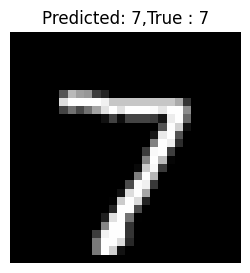

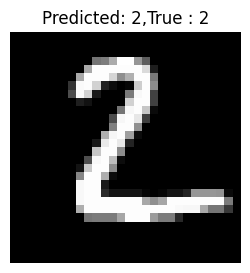

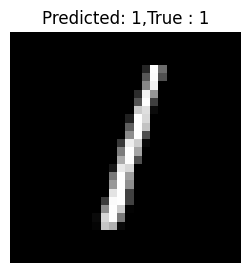

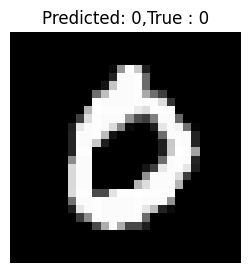

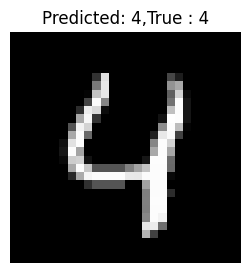

In [73]:
for i in range(5):
    plt.figure(figsize=(3,3))
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title(f'Predicted: {predicted_classes[i]},True : {true_classes[i]}' )
    plt.axis('off')
    plt.show()

In [74]:
model.save("mnist_cnn.keras")

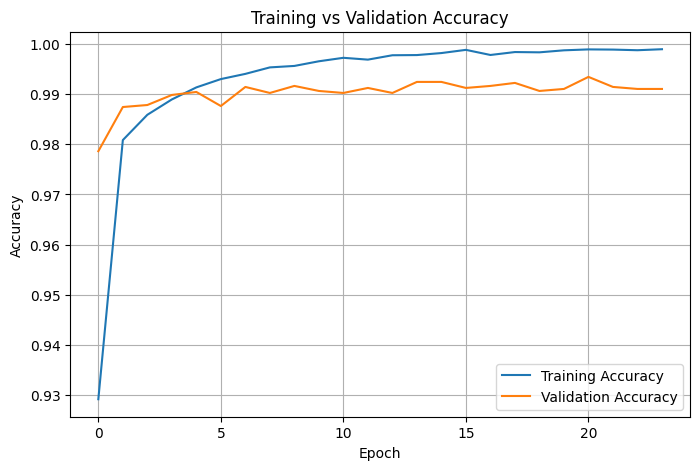

In [75]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

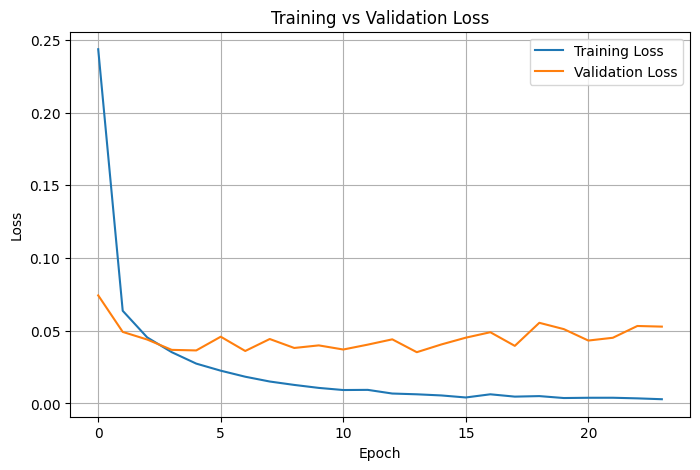

In [76]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

In [78]:
y_pred = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [79]:
y_pred_classes = np.argmax(y_pred, axis=1)

In [80]:
y_true = np.argmax(y_test, axis=1)

In [81]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred_classes)

print(cm)

[[ 977    0    0    0    0    1    0    1    1    0]
 [   1 1125    0    1    1    2    2    0    3    0]
 [   1    0 1024    0    0    0    1    4    2    0]
 [   1    0    1 1000    0    4    0    2    2    0]
 [   0    0    0    0  973    0    4    1    0    4]
 [   1    0    0    3    0  883    2    0    1    2]
 [   3    2    1    0    1    1  950    0    0    0]
 [   0    2    1    0    0    0    0 1023    0    2]
 [   3    0    0    1    0    1    1    2  961    5]
 [   0    0    0    0    4    3    0    4    1  997]]


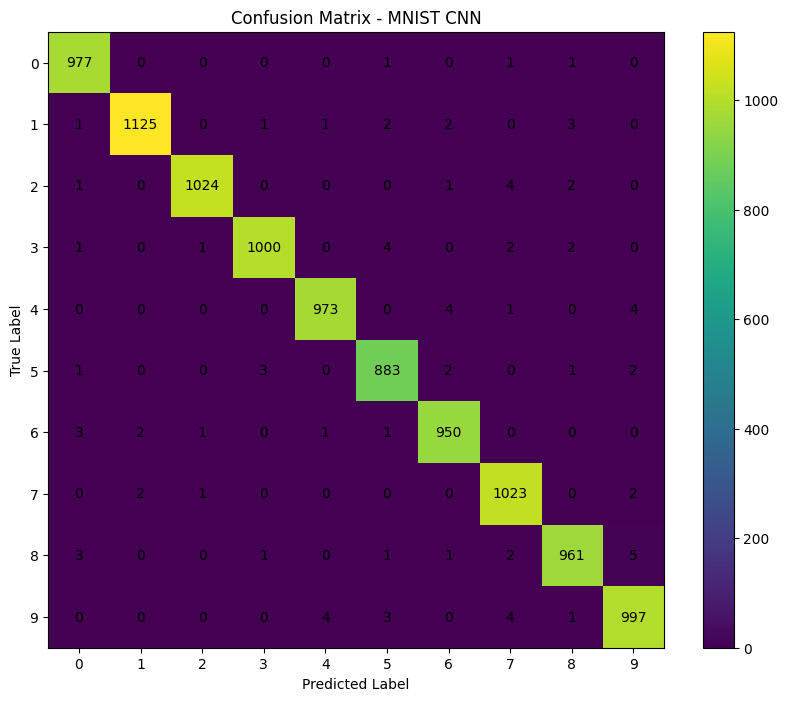

In [83]:
plt.figure(figsize=(10, 8))

plt.imshow(cm)

plt.title('Confusion Matrix - MNIST CNN')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.colorbar()

plt.xticks(np.arange(10))
plt.yticks(np.arange(10))

for i in range(10):
    for j in range(10):
        plt.text(
            j,
            i,
            cm[i, j],
            ha='center',
            va='center'
        )

plt.show()

In [84]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred_classes,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.9899    0.9969    0.9934       980
           1     0.9965    0.9912    0.9938      1135
           2     0.9971    0.9922    0.9947      1032
           3     0.9950    0.9901    0.9926      1010
           4     0.9939    0.9908    0.9924       982
           5     0.9866    0.9899    0.9882       892
           6     0.9896    0.9916    0.9906       958
           7     0.9865    0.9951    0.9908      1028
           8     0.9897    0.9867    0.9882       974
           9     0.9871    0.9881    0.9876      1009

    accuracy                         0.9913     10000
   macro avg     0.9912    0.9913    0.9912     10000
weighted avg     0.9913    0.9913    0.9913     10000



In [85]:
model.save("mnist_cnn.keras")

In [86]:
import os

print(os.path.exists("mnist_cnn.keras"))

True


In [87]:
from tensorflow import keras

loaded_model = keras.models.load_model("mnist_cnn.keras")

print("Model loaded successfully!")

Model loaded successfully!


In [88]:
test_loss, test_accuracy = loaded_model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9913 - loss: 0.0320
Test Accuracy: 99.13%
